# ROGII — Baselines on the frozen CV (B1 / B2 / B3)

The first models, scored on the locked 5-fold well-level CV (`data/processed/cv-folds.parquet`). All three
are per-well rules using only columns present in the test files (`TVT_input`, `Z`, `MD`) — no GR, no
learning across wells. Implementations live in [`src/baselines.py`](../../src/baselines.py); the scoring
harness in [`src/eval.py`](../../src/eval.py).

| | Rule | Formula (anchor = last known row) |
|---|---|---|
| **B1** carry-forward | hold the last known TVT flat | `pred = TVT_input[last]` |
| **B2** −Z + offset | assume TVT moves 1:1 with −Z | `pred = (TVT_input[last] + Z[last]) − Z` |
| **B3** −Z + offset + dip | B2 plus a linear drift fitted pre-PS | `pred = (a + b·MD) − Z`, fit on `TVT_input + Z` |

B2/B3 encode the **geometry hypothesis** (`TVT = −Z + D`, D small and smooth) drawn from whole-well EDA.
That hypothesis is **refuted** here; the full post-mortem with corrected statistics is
[`../eda/03-eda-post-ps.ipynb`](../eda/03-eda-post-ps.ipynb).

*Scoring: pooled RMSE over every post-PS row of every well, each well scored while held out of its fold —
the same protocol as the leaderboard.*

## 1. Run

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "axes.edgecolor": "#888",
})
BAR, MED = "#4C78A8", "#E45756"

def find_root():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / "data" / "raw" / "train").is_dir():
            return c.resolve()
    raise FileNotFoundError("competition root not found")

ROOT = find_root()
sys.path.insert(0, str(ROOT / "src"))
import cv_folds, eval as ev
from baselines import BASELINES

folds = cv_folds.load_folds(ROOT / "data" / "processed" / "cv-folds.parquet")
assert len(folds) == 773
res = ev.score_baselines(BASELINES, folds, ROOT / "data" / "raw")
b1 = res["B1 carry-forward"]["pooled_rmse"]
assert 15.0 <= b1 <= 16.0, f"B1 gate violated: {b1}"
print(f"scored rows: {res['B1 carry-forward']['n_rows']:,}  |  B1 gate OK: {b1:.2f}")

scored rows: 3,783,989  |  B1 gate OK: 15.91


## 2. Results

In [2]:
meta = {
    "B1 carry-forward":  ("the do-nothing floor: TVT never moves",            "the floor to beat"),
    "B2 -Z+offset":      ("value of anchoring on physical depth (-Z)",        "REFUTED — 6.8x worse than B1"),
    "B3 -Z+offset+dip":  ("B2 + extrapolating the pre-PS drift of D",         "REFUTED — 4.6x worse than B1"),
}
rows = [{"baseline": k, "pooled CV RMSE (ft)": round(res[k]["pooled_rmse"], 2),
         "what it isolates": meta[k][0], "verdict": meta[k][1]} for k in BASELINES]
tab = pd.DataFrame(rows)
display(tab.style.hide(axis="index").set_caption("Baselines on the frozen 5-fold CV (773 wells, post-PS rows only)")
        .set_properties(**{"text-align": "left", "font-size": "12px", "padding": "4px 12px"})
        .set_table_styles([
            {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"),
                                               ("text-align", "left"), ("padding", "6px 0")]},
            {"selector": "th", "props": [("text-align", "left"), ("background", "#eef1f6"),
                                         ("padding", "4px 12px")]}]))

baseline,pooled CV RMSE (ft),what it isolates,verdict
B1 carry-forward,15.910000,the do-nothing floor: TVT never moves,the floor to beat
B2 -Z+offset,107.490000,value of anchoring on physical depth (-Z),REFUTED — 6.8x worse than B1
B3 -Z+offset+dip,73.080000,B2 + extrapolating the pre-PS drift of D,REFUTED — 4.6x worse than B1


## 3. B1's error shape — what the 15.91 is made of

Left: most wells are easy under B1 (median ~10.7 ft); a heavy tail of high-drift wells does the damage.
Right: the cumulative share of total squared error owned by the worst wells — the gap to the leaders (~8–9)
is concentrated, not uniform.

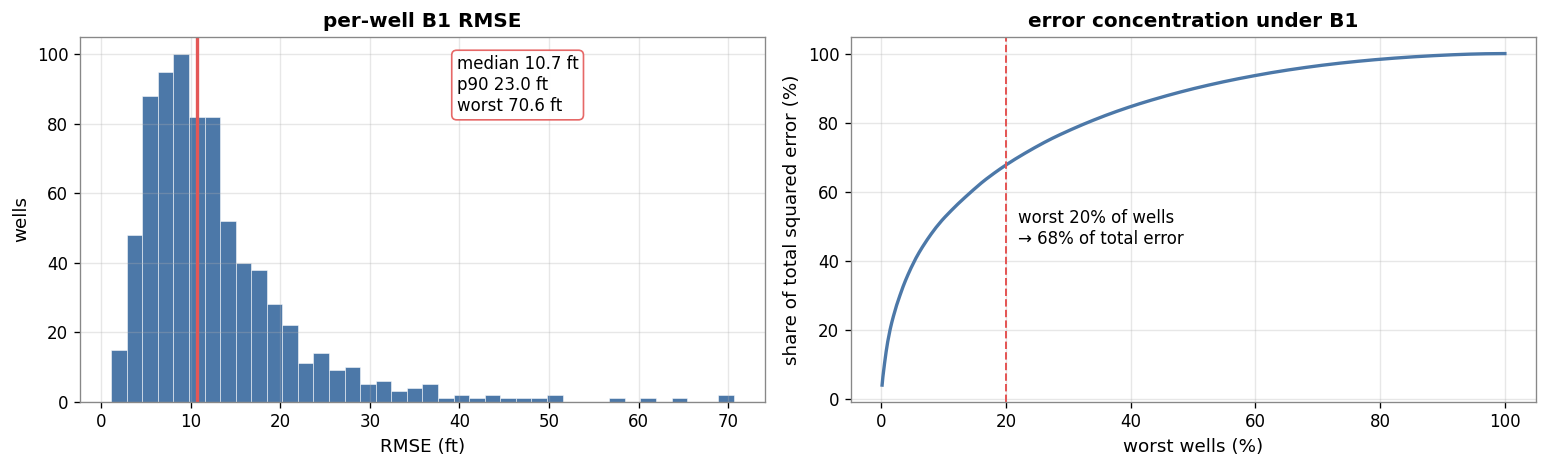

In [3]:
pw = res["B1 carry-forward"]["per_well"]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
d = pw["rmse"]
ax[0].hist(d, bins=40, color=BAR, edgecolor="white", linewidth=0.3)
med = d.median(); ax[0].axvline(med, color=MED, lw=2)
ax[0].text(0.55, 0.95, f"median {med:.1f} ft\np90 {d.quantile(.9):.1f} ft\nworst {d.max():.1f} ft",
           transform=ax[0].transAxes, va="top", fontsize=10,
           bbox=dict(boxstyle="round", fc="white", ec=MED, alpha=0.9))
ax[0].set_title("per-well B1 RMSE"); ax[0].set_xlabel("RMSE (ft)"); ax[0].set_ylabel("wells")

sse = (pw["rmse"]**2 * pw["n_rows"]).sort_values(ascending=False)
share = sse.cumsum() / sse.sum()
x = np.arange(1, len(share)+1) / len(share) * 100
ax[1].plot(x, share*100, color=BAR, lw=2)
k20 = share.iloc[int(len(share)*0.2)-1]*100
ax[1].axvline(20, color=MED, lw=1.2, ls="--")
ax[1].text(22, 45, f"worst 20% of wells\n→ {k20:.0f}% of total error", fontsize=10)
ax[1].set_xlabel("worst wells (%)"); ax[1].set_ylabel("share of total squared error (%)")
ax[1].set_title("error concentration under B1")
plt.tight_layout(); plt.show()

## 4. Findings

- **B1 = 15.91 ft pooled RMSE is the locked floor.** It reproduces the publicly known flat-baseline score,
  which independently certifies the CV harness, fold freezing, and PS contract end-to-end.
- **B2 (107.5) and B3 (73.1) refute the geometry hypothesis.** In the scored region the driller steers to
  hold TVT nearly constant (~26 ft median excursion) while physical depth Z absorbs ~6× larger structural
  swings; anchoring on −Z imports those swings as error, and the pre-PS drift of `D = TVT + Z` does not
  carry past PS (slope transfer corr 0.00). Full corrected statistics:
  [`../eda/03-eda-post-ps.ipynb`](../eda/03-eda-post-ps.ipynb) §8.
- **B1's error is concentrated** in a minority of high-excursion wells deep past PS — the target for the
  next model.
- **Next:** GR–typewell sequence alignment under a smoothness prior, anchored at PS — the only information
  channel the EDA leaves standing.